# Final Project: Benchmarking Multi-Temporal Fusion and Generative Cloud Removal for Sentinel-2 Urban Planning Imagery

**Group Members:** `Chuan Zou, Demi Yang, Christine Cui`  
**Submission Date:** April 23, 2026  
**Submission File:** `assignments/final_project.ipynb`

This notebook reconstructs the full end-to-end project workflow from the repository. The training cells are preserved for reproducibility, but **the submitted results are loaded from saved CSV files and pre-rendered figures** so the notebook can be reviewed quickly without retraining the models.


<div style="border: 2px solid #c62828; padding: 14px 16px; border-radius: 8px; background: #fff5f5; color: #c62828; font-weight: 700; font-size: 16px; line-height: 1.5;">
Important note: The project source code is organized and executed as engineering-style Python scripts and modules. This notebook is mainly used for important code presentation, logic explanation, and final result display. For that reason, some code blocks are pasted here directly to show the model architecture and implementation details rather than being executed end-to-end inside the notebook.

GitHub Link: github.com/chuanzou/Geo-Evaluate

</div>


In [7]:
from pathlib import Path
import csv
import sys
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'cloud_removal').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / 'assignments' / 'final_project_files'
FIG_DIR = ARTIFACT_DIR / 'figures_jpg'
RUN_HEAVY_CELLS = False
sys.path.insert(0, str(ROOT / 'src'))


def read_csv_rows(path: Path):
    with path.open('r', encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))


print(f'ROOT            = {ROOT}')
print(f'ARTIFACT_DIR    = {ARTIFACT_DIR}')
print(f'RUN_HEAVY_CELLS = {RUN_HEAVY_CELLS}')
print('This notebook is configured to read stored metrics/figures rather than retrain models.')


ROOT            = /Users/bot_base/Geo-Evaluate
ARTIFACT_DIR    = /Users/bot_base/Geo-Evaluate/assignments/final_project_files
RUN_HEAVY_CELLS = False
This notebook is configured to read stored metrics/figures rather than retrain models.


## 1. Problem Definition & Technical Justification

### Problem
Urban planners often need cloud-free satellite imagery to inspect land cover, vegetation, transportation corridors, and newly developed built-up areas. In practice, even during the growing season, many scenes are partially obscured by clouds. Our project studies whether we can reconstruct cloud-covered Sentinel-2 image patches well enough to support downstream interpretation in an urban-planning context.

### Target User
The target user is a **municipal or regional planning analyst** who wants a cleaner four-band patch for visual inspection and vegetation analysis, especially when a fully cloud-free scene is not available on the exact date of interest.

### Output
The system outputs a **cloud-reduced 4-band patch** (`red`, `green`, `blue`, `nir`) and supports downstream NDVI calculation for vegetation-sensitive analysis.

### What the models are actually learning
- The **temporal baseline** learns nothing; it simply fuses multiple observations by averaging pixels that are cloud-free in at least one frame.
- The **conditional GAN** learns a direct mapping from `(cloudy image + cloud mask)` to the cloud-free target patch.
- The **diffusion model** learns to predict noise inside the cloud mask so that a reverse denoising process can reconstruct plausible missing content.

### Why this approach is technically justified
This problem has two natural solution families, and we implemented both.
- If enough redundant observations exist, a simple multi-temporal composite should work extremely well.
- If the cloud region is too large, the model must rely on learned spatial and spectral priors rather than direct observation.

That is why this benchmark compares a **simple non-learned baseline** against **learned generative methods** rather than testing only one deep model in isolation.

### Anticipated failure modes
We expected four failure modes before implementation:
1. **Temporal failure under heavy cloud cover** when every observation is cloudy at the same pixel.
2. **Spectral inconsistency** where RGB may look reasonable but NIR/NDVI is wrong.
3. **Urban texture smoothing or hallucination** in bright built-up areas with sharp boundaries.
4. **Training instability** in small generative models with limited data and compute.

### What we actually observed
All four appeared in practice.
- The temporal baseline was nearly perfect at low coverage and then collapsed sharply once the probability of all observations being cloudy became non-negligible.
- Diffusion was consistently weaker on **NDVI MAE**, indicating poorer cross-channel consistency.
- Both learned models smoothed high-frequency urban structure at very high cloud coverage, though GAN handled this substantially better than diffusion.
- Diffusion required debugging: the final activation and initialization scheme mattered a lot, and fixing those details was necessary before the model produced usable results.


## 2. Methodological Precedent

Four main references shaped the final design.

1. **U-Net**: Ronneberger, Fischer, and Brox, *U-Net: Convolutional Networks for Biomedical Image Segmentation* ([arXiv:1505.04597](https://arxiv.org/abs/1505.04597)).  
   This paper motivated the compact encoder-decoder backbone with skip connections that we reused for both learned models.

2. **pix2pix / conditional GANs**: Isola et al., *Image-to-Image Translation with Conditional Adversarial Networks* ([arXiv:1611.07004](https://arxiv.org/abs/1611.07004)).  
   This directly informed the GAN setup: a U-Net-style generator, a PatchGAN discriminator, and an adversarial-plus-reconstruction objective.

3. **DDPM**: Ho, Jain, and Abbeel, *Denoising Diffusion Probabilistic Models* ([arXiv:2006.11239](https://arxiv.org/abs/2006.11239)).  
   This provided the forward-noising / reverse-denoising formulation used in our diffusion baseline.

4. **Mask-guided diffusion inpainting**: Lugmayr et al., *RePaint: Inpainting using Denoising Diffusion Probabilistic Models* ([arXiv:2201.09865](https://arxiv.org/abs/2201.09865)).  
   This shaped the decision to keep known pixels fixed outside the cloud mask during reverse sampling.

On the data side, the project also relied on the **Google Earth Engine data catalog entry for `COPERNICUS/S2_SR_HARMONIZED`** and the **ESA Sentinel-2 mission description** to justify the band choice, revisit frequency, and surface-reflectance workflow.


---

## 3. Data & Preprocessing

### Dataset
The benchmark is built from cloud-free Sentinel-2 surface-reflectance patches exported over Beijing and nearby urban/rural surroundings.

- **Sensor / product:** Sentinel-2 Level-2A surface reflectance (`COPERNICUS/S2_SR_HARMONIZED`)
- **AOI:** Beijing region
- **Time span:** April through October 2023
- **Bands used:** `B4` (red), `B3` (green), `B2` (blue), `B8` (NIR)
- **Resolution:** 10 m
- **Patch size:** `128 x 128`
- **Base cloud-free patches:** 3,000
- **Synthetic coverage bins:** 5%, 10%, 30%, 50%, 70%

### Preprocessing decisions that mattered
1. **GeoTIFF to NumPy conversion**  
   The repository converts 4-band GeoTIFF patches into `(4, 128, 128)` NumPy arrays and auto-detects whether the inputs are already in reflectance space, preventing accidental double division by 10,000.

2. **Finite-value cleanup**  
   NaN and infinite values are replaced before training so that downstream optimization stays numerically stable.

3. **Synthetic cloud generation**  
   Instead of relying on noisy real cloud labels, we generate smooth cloud masks with Gaussian-filtered noise and threshold them to exact coverage targets. This creates a controlled benchmark where the ground truth is always known.

4. **Leakage-safe splitting**  
   The train/val/test split is done at the **base-image level** before cloud variants are created. That prevents different cloud versions of the same patch from leaking across splits.

5. **Derived-file filtering**  
   The dataset-preparation script explicitly ignores previously generated `_cNN` files so the benchmark does not recursively contaminate its own ground truth.

### Why the synthetic setup is still useful
The synthetic benchmark is not a full replacement for real cloud removal, but it is very useful for controlled comparison because every method sees the **same scene content**, **same cloud coverage bins**, and **same exact target image**.


### 3.1 Environment Setting


In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import warnings
from dataclasses import dataclass
import pandas as pd
from scipy.ndimage import gaussian_filter

warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

Using device: cpu


### 3.2 Code: convert_geotiff_to_npy.py script

In [ ]:
#1. Data Download from Sentinel-2 and Preprocessing
# GeoTIFF data should first be downloaded and then converted into NumPy arrays.
# The processed data is stored in `data/processed/synthetic_cloud_benchmark`.
# The following code is pasted from `convert_geotiff_to_npy.py`.
def convert_tif_to_npy(input_dir, output_dir):
    """Convert Sentinel-2 GeoTIFF patches to (4, 128, 128) float32 npy files
    in the [0, 1] reflectance range.

    ``download_sentinel2_beijing.py`` already divides by 10000 on the Earth
    Engine side, so the exported TIFs are already in [0, 1].  An older
    version of this script divided by 10000 a *second* time, silently
    collapsing every value to ~1e-5 which became 0.0 after float32
    round-trip + clip — that's what caused "perfect" GAN metrics earlier.
    We now auto-detect the input range:

      * if max > 2   → assume raw DN units, divide by 10000
      * else         → already reflectance, leave alone

    Any NaN/Inf is zeroed out so downstream training never sees non-finite.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    files = [f for f in os.listdir(input_dir) if f.endswith('.tif')]
    if not files:
        print(f"Error: no .tif files were found in {input_dir}!")
        return

    print(f"Starting conversion for {len(files)} files...")

    scaled_count = 0
    already_ok_count = 0
    zero_samples = []

    for f in tqdm(files):
        try:
            with rasterio.open(os.path.join(input_dir, f)) as src:
                # B4, B3, B2, B8  →  Red, Green, Blue, NIR
                img = src.read([1, 2, 3, 4]).astype(np.float32)
                img = np.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0)

                max_val = float(img.max())
                if max_val > 2.0:
                    img = img / 10000.0
                    scaled_count += 1
                else:
                    already_ok_count += 1

                img = np.clip(img, 0.0, 1.0)
                # Crop to 128 x 128
                img = img[:, :128, :128]

                if img.shape != (4, 128, 128):
                    print(f"Warning: {f} has shape {img.shape} after conversion; skipping it.")
                    continue

                if img.max() == 0.0:
                    zero_samples.append(f)

                output_filename = f.replace('.tif', '.npy')
                np.save(os.path.join(output_dir, output_filename), img)
        except Exception as e:
            print(f"Error while processing file {f}: {e}")

    print(
        f"\nFinished: scaled {scaled_count} files by /10000, left {already_ok_count} unchanged, "
        f"found {len(zero_samples)} all-zero samples"
    )
    if zero_samples[:5]:
        print("Examples of all-zero samples (possibly fully masked empty Earth Engine patches):", zero_samples[:5])


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Convert GeoTIFF files to NumPy arrays")
    parser.add_argument("--input-dir", type=str, required=True, help="Path to the input TIFF directory")
    parser.add_argument("--output-dir", type=str, required=True, help="Path to the output NPY directory")

    args = parser.parse_args()
    convert_tif_to_npy(args.input_dir, args.output_dir)

### 3.3 Cloudy Data Generation Code

In [12]:
@dataclass(frozen=True)
class CloudSample:
    """Container for cloud-corrupted image data."""
    cloudy: np.ndarray
    mask: np.ndarray
    coverage: float

def make_cloud_mask(
    height: int,
    width: int,
    coverage: float,
    rng: np.random.Generator,
    smooth_sigma: float | None = None,
) -> np.ndarray:
    """Create organic-shaped cloud mask with approximate target coverage."""
    if not 0.0 <= coverage <= 1.0:
        raise ValueError("coverage must be between 0 and 1")

    smooth_sigma = smooth_sigma or max(height, width) / 18
    noise = rng.normal(size=(height, width)).astype(np.float32)
    smooth = gaussian_filter(noise, sigma=smooth_sigma)
    threshold = np.quantile(smooth, 1.0 - coverage)
    return (smooth >= threshold).astype(np.float32)

def apply_cloud(
    image: np.ndarray,
    coverage: float,
    rng: np.random.Generator,
    cloud_value: float = 1.0,
) -> CloudSample:
    """Overlay synthetic white clouds on a normalized CxHxW image."""
    if image.ndim != 3:
        raise ValueError("image must have shape CxHxW")

    _, height, width = image.shape
    mask = make_cloud_mask(height, width, coverage, rng)
    cloud_layer = np.full_like(image, cloud_value, dtype=np.float32)
    cloudy = image * (1.0 - mask[None, ...]) + cloud_layer * mask[None, ...]
    return CloudSample(cloudy=np.clip(cloudy, 0.0, 1.0), mask=mask, coverage=float(mask.mean()))

def random_sentinel_like_patch(
    image_size: int,
    rng: np.random.Generator,
    channels: int = 4,
) -> np.ndarray:
    """Generate synthetic Sentinel-2-like satellite patch (RGBN)."""
    yy, xx = np.mgrid[0:image_size, 0:image_size].astype(np.float32)
    xx = xx / max(image_size - 1, 1)
    yy = yy / max(image_size - 1, 1)

    base = 0.25 + 0.35 * xx + 0.20 * yy
    fields = ((np.sin(xx * rng.uniform(12, 24)) + np.cos(yy * rng.uniform(10, 20))) > 0).astype(np.float32)
    urban = (((xx * image_size).astype(int) % rng.integers(10, 18)) < 2).astype(np.float32)
    vegetation = np.clip(base + 0.30 * fields - 0.12 * urban, 0.0, 1.0)

    red = np.clip(vegetation * 0.75 + rng.normal(0, 0.03, (image_size, image_size)), 0.0, 1.0)
    green = np.clip(vegetation * 0.88 + rng.normal(0, 0.03, (image_size, image_size)), 0.0, 1.0)
    blue = np.clip(vegetation * 0.62 + rng.normal(0, 0.03, (image_size, image_size)), 0.0, 1.0)
    nir = np.clip(vegetation * 1.15 + 0.15 * fields + rng.normal(0, 0.03, (image_size, image_size)), 0.0, 1.0)
    patch = np.stack([red, green, blue, nir], axis=0).astype(np.float32)
    return patch[:channels]

print("✓ Data generation module loaded")

✓ Data generation module loaded


### 3.3 PROCESS VISUALIZATION: Dataset Summary from the Final Configuration

In [14]:
config_rows = [
    ['AOI', 'Beijing and surrounding region'],
    ['Satellite product', 'COPERNICUS/S2_SR_HARMONIZED (Sentinel-2 Level-2A surface reflectance)'],
    ['Time window', 'April 1, 2023 to October 31, 2023'],
    ['Bands used', 'Red (B4), Green (B3), Blue (B2), NIR (B8)'],
    ['Spatial resolution', '10 meters'],
    ['Patch size', '128 x 128 pixels'],
    ['Ground-truth patches', '3,000 cloud-free base patches'],
    ['Coverage bins', '5%, 10%, 30%, 50%, 70%'],
    ['Derived samples', '15,000 total synthetic cloudy samples'],
    ['Split strategy', '70% train / 10% val / 20% test at the base-image level'],
    ['Split counts', '10,500 train / 1,500 val / 3,000 test'],
    ['Temporal neighbors', '3 extra observations during temporal evaluation'],
]

html_rows = ''.join(
    '<tr>' + ''.join(f'<td>{field}</td>' for field in row) + '</tr>'
    for row in config_rows
)
from IPython.display import HTML
HTML('<table><thead><tr><th>Field</th><th>Value</th></tr></thead><tbody>' + html_rows + '</tbody></table>')


Field,Value
AOI,Beijing and surrounding region
Satellite product,COPERNICUS/S2_SR_HARMONIZED (Sentinel-2 Level-2A surface reflectance)
Time window,"April 1, 2023 to October 31, 2023"
Bands used,"Red (B4), Green (B3), Blue (B2), NIR (B8)"
Spatial resolution,10 meters
Patch size,128 x 128 pixels
Ground-truth patches,"3,000 cloud-free base patches"
Coverage bins,"5%, 10%, 30%, 50%, 70%"
Derived samples,"15,000 total synthetic cloudy samples"
Split strategy,70% train / 10% val / 20% test at the base-image level


### Synthetic Cloud Generation Example

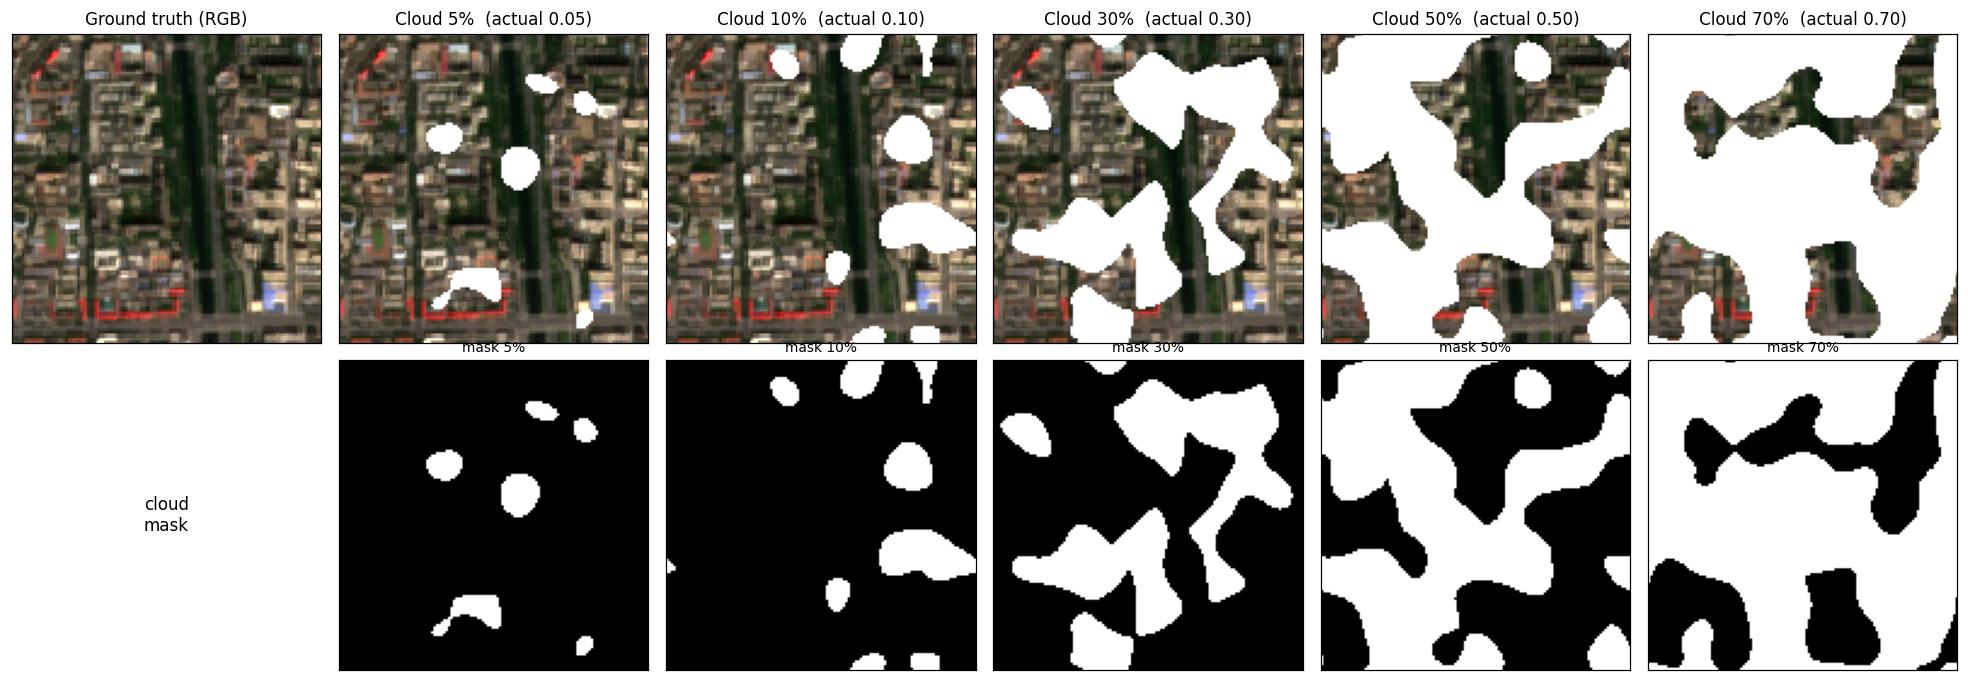

*Figure 1. A single cloud-free patch transformed into five synthetic cloud-coverage bins. This controlled setup is what makes direct metric comparison possible.*


---

## 4. Modeling Approach

### 4.1 Baseline model: multi-temporal fusion
The baseline is intentionally simple: it averages pixels that are clear in at least one observation and falls back to the original cloudy observation where every frame is masked. This gives us a strong non-deep-learning performance floor.

Its core limitation is easy to reason about: if all observations are cloudy at a pixel, the baseline has no information left to recover the truth.


In [3]:
rows = []
for coverage in [0.05, 0.10, 0.30, 0.50, 0.70]:
    p_all = coverage ** 4  # 1 original cloudy frame + 3 temporal neighbors
    expected_pixels = p_all * 128 * 128
    rows.append((coverage, p_all, expected_pixels))

html_rows = ''.join(
    f'<tr><td>{coverage:.0%}</td><td>{p_all:.6f}</td><td>{expected_pixels:.1f}</td></tr>'
    for coverage, p_all, expected_pixels in rows
)
from IPython.display import HTML
HTML(
    '<table><thead><tr><th>Cloud coverage</th><th>P(all 4 frames cloudy)</th>'
    '<th>Expected fully-missing pixels in a 128x128 patch</th></tr></thead><tbody>'
    + html_rows + '</tbody></table>'
)


Cloud coverage,P(all 4 frames cloudy),Expected fully-missing pixels in a 128x128 patch
5%,0.000006,0.1
10%,0.000100,1.6
30%,0.008100,132.7
50%,0.062500,1024.0
70%,0.240100,3933.8


The table above explains the sharp temporal crossover we later observe in the results. At 5% and 10% coverage, the baseline almost always sees a clear pixel somewhere. By 50% and 70%, that assumption breaks badly.

### 4.2 Primary learned model: conditional GAN
The **main learned model in the final report is the conditional GAN**, because it is the strongest deep model in the benchmark.

- **Input:** cloudy 4-band patch plus 1-channel cloud mask
- **Backbone:** compact U-Net generator
- **Discriminator:** PatchGAN on the concatenated input/target pair
- **Loss:** adversarial loss plus `100 x L1`

### 4.3 Additional learned comparator: mask-guided diffusion
We also implemented a small diffusion-style inpainting model using the same U-Net backbone.

- **Input to denoiser:** conditioned image, cloud mask, and normalized timestep channel
- **Training target:** predicted noise inside the cloud region
- **Inference:** reverse diffusion while re-imposing known clean pixels outside the mask at every step

This diffusion model is useful analytically even though it is not the strongest final method, because it reveals how different objectives affect visual realism versus spectral consistency.


### Shared Backbone Diagram

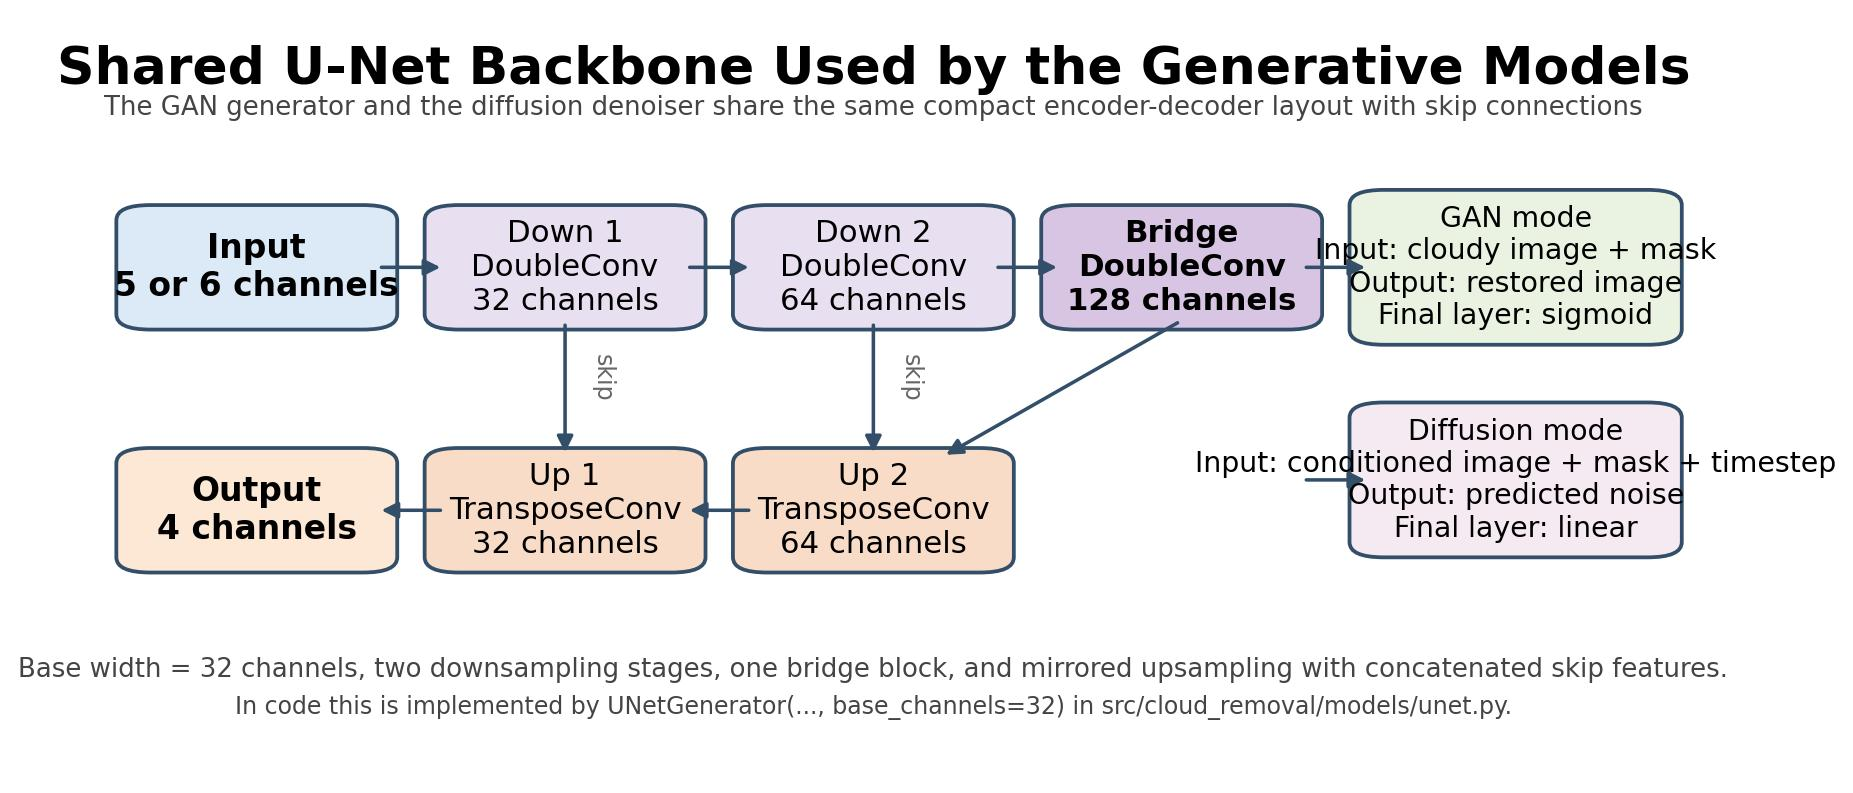

*Figure 2. The learned models share the same compact U-Net backbone. The main difference is the input semantics and the final layer: sigmoid for the GAN generator, linear for the diffusion denoiser.*


### Model Definition Code (Pasted from the Source Files, Not Executed Here)

The following blocks are pasted directly from the project source code so the notebook clearly shows the actual model-definition logic. They are included for documentation and presentation purposes and are **not meant to be executed inside this notebook**.


### Definition Code: Temporal Baseline (`src/cloud_removal/models/baseline.py`)

```python
import torch


def multi_temporal_composite(
    cloudy_stack: torch.Tensor,
    mask_stack: torch.Tensor,
    fallback: torch.Tensor | None = None,
) -> torch.Tensor:
    """Fuse temporal observations by averaging cloud-free pixels."""
    if cloudy_stack.ndim != 4 or mask_stack.ndim != 4:
        raise ValueError("cloudy_stack and mask_stack must be TxCxHxW and Tx1xHxW")

    clear = 1.0 - mask_stack
    weighted_sum = (cloudy_stack * clear).sum(dim=0)
    clear_count = clear.sum(dim=0).clamp_min(1e-6)
    composite = weighted_sum / clear_count

    if fallback is not None:
        no_clear = (clear.sum(dim=0) <= 1e-6).expand_as(composite)
        composite = torch.where(no_clear, fallback, composite)
    return composite.clamp(0.0, 1.0)
```


### Definition Code: GAN Components (`src/cloud_removal/models/unet.py`)



```python
import torch
from torch import nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetGenerator(nn.Module):
    def __init__(
        self,
        in_channels: int = 5,
        out_channels: int = 4,
        base_channels: int = 32,
        final_activation: str | None = "sigmoid",
    ):
        super().__init__()
        self.down1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bridge = DoubleConv(base_channels * 2, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)
        final_conv = nn.Conv2d(base_channels, out_channels, 1)
        if final_activation == "sigmoid":
            self.out = nn.Sequential(final_conv, nn.Sigmoid())
        elif final_activation in (None, "none", "linear"):
            self.out = final_conv
        else:
            raise ValueError("Unsupported final activation")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        bridge = self.bridge(self.pool2(d2))
        u2 = self.up2(bridge)
        u2 = torch.cat([u2, d2], dim=1)
        u1 = self.up1(self.dec2(u2))
        u1 = torch.cat([u1, d1], dim=1)
        return self.out(self.dec1(u1))


class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels: int = 9, base_channels: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 2, base_channels * 4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels * 4, 1, 3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
```


### Definition Code: Diffusion Model (`src/cloud_removal/models/diffusion.py`)

```python
import torch
from torch import nn

from cloud_removal.models.unet import UNetGenerator


class InpaintingDiffusion(nn.Module):
    """Compact DDPM-style model for mask-guided inpainting experiments."""

    def __init__(self, channels: int = 4, timesteps: int = 100):
        super().__init__()
        self.channels = channels
        self.timesteps = timesteps
        self.denoiser = UNetGenerator(
            in_channels=channels + 2,
            out_channels=channels,
            final_activation=None,
        )

        betas = torch.linspace(1e-4, 0.02, timesteps)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_bars", alpha_bars)

    def add_noise(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
        return alpha_bar.sqrt() * x0 + (1.0 - alpha_bar).sqrt() * noise

    def forward_at_t(
        self,
        cloudy: torch.Tensor,
        mask: torch.Tensor,
        target: torch.Tensor,
        t: torch.Tensor,
        noise: torch.Tensor,
    ) -> torch.Tensor:
        batch = target.shape[0]
        noisy = self.add_noise(target, t, noise)
        t_channel = t.float().view(batch, 1, 1, 1) / max(self.timesteps - 1, 1)
        t_channel = t_channel.expand(-1, 1, target.shape[-2], target.shape[-1])
        conditioned = noisy * mask + cloudy * (1.0 - mask)
        predicted_noise = self.denoiser(torch.cat([conditioned, mask, t_channel], dim=1))
        return predicted_noise

    def forward(
        self, cloudy: torch.Tensor, mask: torch.Tensor, target: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        batch = target.shape[0]
        t = torch.randint(0, self.timesteps, (batch,), device=target.device)
        noise = torch.randn_like(target)
        predicted_noise = self.forward_at_t(cloudy, mask, target, t, noise)
        return predicted_noise, noise, t

    @torch.no_grad()
    def inpaint(self, cloudy: torch.Tensor, mask: torch.Tensor, steps: int | None = None) -> torch.Tensor:
        del steps
        alpha_bar_last = self.alpha_bars[-1]
        clean_weight = 1.0 - mask
        clean_denom = clean_weight.sum(dim=(-2, -1), keepdim=True).clamp(min=1.0)
        clean_mean = (cloudy * clean_weight).sum(dim=(-2, -1), keepdim=True) / clean_denom
        target_proxy = clean_mean.expand_as(cloudy)

        noise_init = torch.randn_like(cloudy)
        x = alpha_bar_last.sqrt() * target_proxy + (1.0 - alpha_bar_last).sqrt() * noise_init
        x = x * mask + cloudy * (1.0 - mask)

        for step in reversed(range(self.timesteps)):
            t_channel = torch.full(
                (cloudy.shape[0], 1, cloudy.shape[-2], cloudy.shape[-1]),
                step / max(self.timesteps - 1, 1),
                device=cloudy.device,
            )
            predicted_noise = self.denoiser(torch.cat([x, mask, t_channel], dim=1))
            alpha_bar = self.alpha_bars[step]
            x0_pred = (x - (1.0 - alpha_bar).sqrt() * predicted_noise) / alpha_bar.sqrt()
            x0_pred = x0_pred.clamp(0.0, 1.0)

            if step > 0:
                alpha_bar_prev = self.alpha_bars[step - 1]
                beta = self.betas[step]
                alpha = self.alphas[step]
                coef_x0 = alpha_bar_prev.sqrt() * beta / (1.0 - alpha_bar)
                coef_xt = alpha.sqrt() * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
                mean = coef_x0 * x0_pred + coef_xt * x
                var = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
                noise = torch.randn_like(x)
                x = mean + var.clamp(min=0.0).sqrt() * noise
            else:
                x = x0_pred

            x = x * mask + cloudy * (1.0 - mask)

        return x.clamp(0.0, 1.0)
```


### Instantiated Model Summaries

The next code cell creates the model objects and prints their parameter counts and module structure summaries.


In [10]:
from cloud_removal.models.unet import UNetGenerator, PatchDiscriminator
from cloud_removal.models.diffusion import InpaintingDiffusion


def count_params(model):
    return sum(p.numel() for p in model.parameters())


gan_generator = UNetGenerator(in_channels=5, out_channels=4)
patch_discriminator = PatchDiscriminator(in_channels=9)
diffusion_model = InpaintingDiffusion(timesteps=100)

print(f'GAN generator parameters      : {count_params(gan_generator):,}')
print(f'PatchGAN discriminator params : {count_params(patch_discriminator):,}')
print(f'Diffusion denoiser parameters : {count_params(diffusion_model):,}')
print()
print('UNetGenerator(in_channels=5, out_channels=4)')
print(gan_generator)
print('PatchDiscriminator(in_channels=9)')
print(patch_discriminator)
print('InpaintingDiffusion(timesteps=100)')
print(diffusion_model)


GAN generator parameters      : 468,484
PatchGAN discriminator params : 170,209
Diffusion denoiser parameters : 468,772

UNetGenerator(in_channels=5, out_channels=4)
UNetGenerator(
  (down1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=

### Training Procedure and Hyperparameters

The repository keeps the full training pipeline, but the notebook does **not** rerun it by default. That is intentional: the submitted analysis should be reproducible without spending hours retraining checkpoints.

Key training choices from `configs/default.yaml`:
- batch size = 4
- learning rate = `5e-5`
- GAN epochs = 8
- diffusion epochs = 50
- diffusion timesteps = 100
- temporal neighbors = 3

The diffusion model needed more epochs because each update only samples one random timestep per example, so its effective learning signal is thinner than the GAN's direct image supervision.


In [9]:
RUN_HEAVY_CELLS = False

commands = [
    'python scripts/download_sentinel2_beijing.py --year 2023 --num-patches 2000 --max-tasks 2000 --drive-folder GeoEvaluate_Beijing_S2',
    'python scripts/convert_geotiff_to_npy.py --input-dir data/raw/sentinel2_beijing --output-dir data/processed/synthetic_cloud_benchmark/ground_truth',
    'python scripts/prepare_synthetic_dataset.py --from-ground-truth',
    'python scripts/run_experiment.py --method temporal --config configs/default.yaml',
    'python scripts/run_experiment.py --method gan --config configs/default.yaml --train',
    'python scripts/run_experiment.py --method diffusion --config configs/default.yaml --train',
    'python scripts/qualitative_grid.py',
    'python scripts/qualitative_error_grid.py',
    'python scripts/plot_loss.py',
]

print('Reproducibility commands included in this notebook (kept for documentation, not executed by default):')
for idx, command in enumerate(commands, start=1):
    print(f'{idx}. {command}')

if RUN_HEAVY_CELLS:
    raise RuntimeError('Heavy training/evaluation is intentionally disabled in the submission notebook.')


Reproducibility commands included in this notebook (kept for documentation, not executed by default):
1. python scripts/download_sentinel2_beijing.py --year 2023 --num-patches 2000 --max-tasks 2000 --drive-folder GeoEvaluate_Beijing_S2
2. python scripts/convert_geotiff_to_npy.py --input-dir data/raw/sentinel2_beijing --output-dir data/processed/synthetic_cloud_benchmark/ground_truth
3. python scripts/prepare_synthetic_dataset.py --from-ground-truth
4. python scripts/run_experiment.py --method temporal --config configs/default.yaml
5. python scripts/run_experiment.py --method gan --config configs/default.yaml --train
6. python scripts/run_experiment.py --method diffusion --config configs/default.yaml --train
7. python scripts/qualitative_grid.py
8. python scripts/qualitative_error_grid.py
9. python scripts/plot_loss.py


### Was the added complexity worth it?
The answer depends on the cloud regime.

- **Low cloud coverage (< 30%)**: no, not really. The temporal baseline is almost perfect and beats both learned models.
- **Moderate to high cloud coverage (>= 30%)**: yes. The GAN especially becomes much better than temporal fusion and stays stable as coverage rises.
- **Diffusion**: informative as a benchmark, but not worth the extra complexity in this specific implementation because it is consistently worse than the GAN and weaker on NDVI preservation.


--- 


## 5. Evaluation & Analysis

We report four main metrics:
- **PSNR** for overall reconstruction fidelity
- **SSIM** for structural similarity in the visible bands
- **Cloud-region L1** for the actual inpainting difficulty
- **NDVI MAE** for spectral faithfulness relevant to vegetation analysis

The most important metric for comparing methods here is **cloud-region L1**, because it isolates the pixels the model actually had to reconstruct.


In [6]:
import csv

summary_rows = []
for name in ['temporal', 'gan', 'diffusion']:
    with open(ARTIFACT_DIR / f'{name}_metrics_by_coverage.csv', 'r', encoding='utf-8', newline='') as f:
        rows = list(csv.DictReader(f))
    for row in rows:
        summary_rows.append([
            name,
            f"{float(row['coverage_bin']):.2f}",
            row['num_samples'],
            f"{float(row['psnr']):.2f}",
            f"{float(row['ssim']):.3f}",
            f"{float(row['l1_cloud_region']):.4f}",
            f"{float(row['ndvi_mae']):.4f}",
        ])

html_rows = ''.join(
    '<tr>' + ''.join(f'<td>{cell}</td>' for cell in row) + '</tr>'
    for row in summary_rows
)
from IPython.display import HTML
HTML(
    '<table><thead><tr><th>Method</th><th>Coverage</th><th>N</th><th>PSNR</th><th>SSIM</th><th>L1 (cloud only)</th><th>NDVI MAE</th></tr></thead><tbody>'
    + html_rows + '</tbody></table>'
)


Method,Coverage,N,PSNR,SSIM,L1 (cloud only),NDVI MAE
temporal,0.05,600,172.67,0.995,0.0004,0.0002
temporal,0.10,600,154.29,0.961,0.0018,0.0011
temporal,0.30,600,24.65,0.363,0.0238,0.0142
temporal,0.50,600,13.33,0.053,0.1095,0.0667
temporal,0.70,600,7.28,0.009,0.3027,0.1821
gan,0.05,600,43.44,0.988,0.0222,0.0995
gan,0.10,600,40.32,0.976,0.0222,0.0994
gan,0.30,600,35.25,0.925,0.0228,0.1039
gan,0.50,600,32.53,0.858,0.0242,0.1108
gan,0.70,600,30.49,0.768,0.0260,0.1234


### Quantitative Comparison Curves

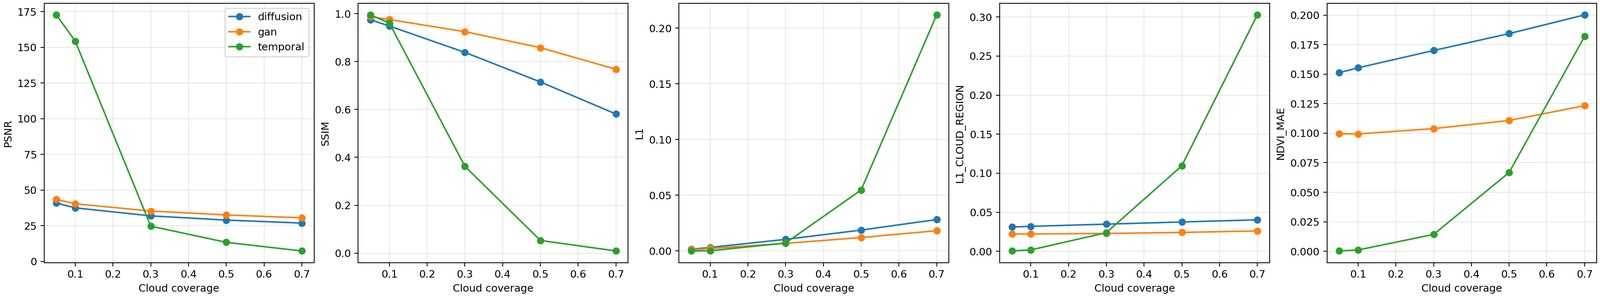

*Figure 3. The temporal baseline dominates at very low coverage and then collapses; GAN is the strongest learned method throughout the medium/high-coverage regime; diffusion is consistently weaker than GAN and especially weak on NDVI.*


### Training Dynamics for the Diffusion Model

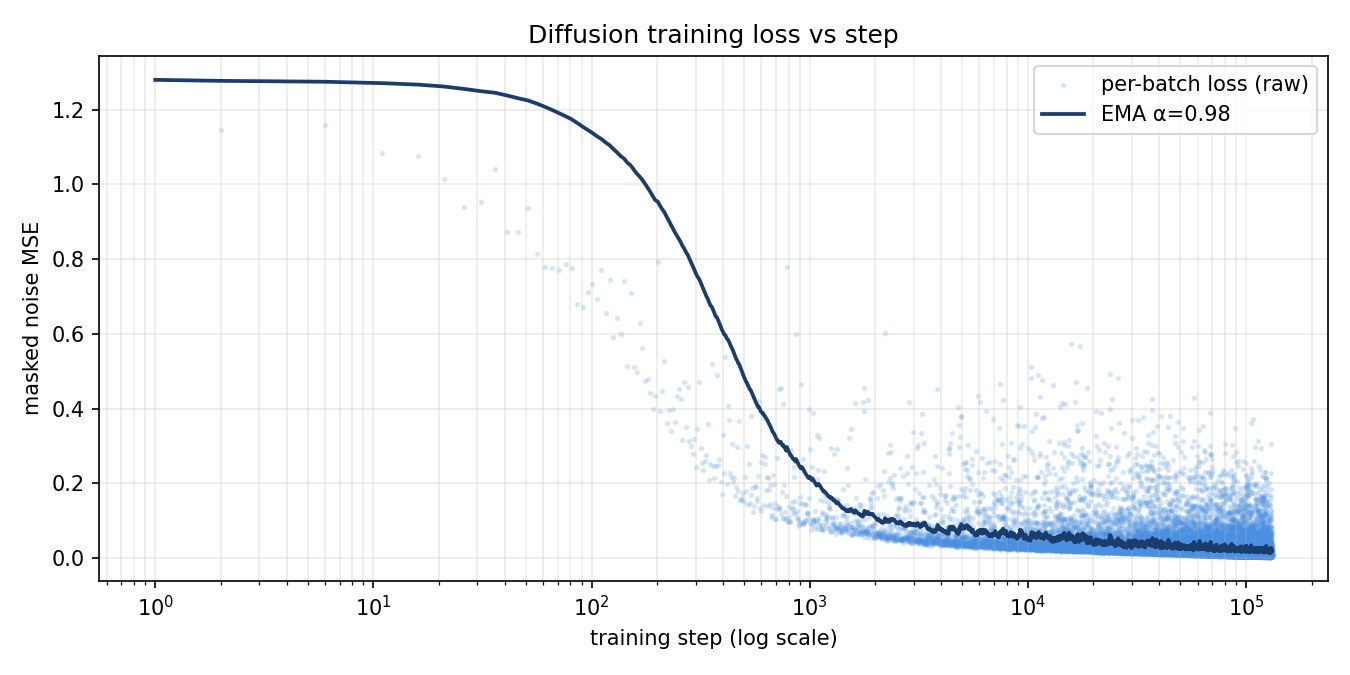

*Figure 4. Diffusion training required a longer schedule and more debugging than the GAN. This figure is loaded from the saved training log visualization rather than regenerated here.*


In [13]:
high_coverages = [0.30, 0.50, 0.70]
metrics = {}
for name in ['temporal', 'gan', 'diffusion']:
    with open(ARTIFACT_DIR / f'{name}_metrics_by_coverage.csv', 'r', encoding='utf-8', newline='') as f:
        metrics[name] = {float(row['coverage_bin']): row for row in csv.DictReader(f)}

for coverage in high_coverages:
    gan_psnr_gain = float(metrics['gan'][coverage]['psnr']) - float(metrics['temporal'][coverage]['psnr'])
    gan_l1_gain = float(metrics['temporal'][coverage]['l1_cloud_region']) - float(metrics['gan'][coverage]['l1_cloud_region'])
    print(
        f'At coverage {coverage:.2f}, GAN improves over temporal by '
        f'{gan_psnr_gain:.2f} dB PSNR and lowers cloud-region L1 by {gan_l1_gain:.4f}.'
    )

print()
for coverage in [0.05, 0.10, 0.30, 0.50, 0.70]:
    ratio = float(metrics['diffusion'][coverage]['ndvi_mae']) / float(metrics['gan'][coverage]['ndvi_mae'])
    print(f'At coverage {coverage:.2f}, diffusion NDVI MAE is {ratio:.2f}x the GAN value.')

print('Average performance over the harder regimes (30%, 50%, 70%):')
for name in ['temporal', 'gan', 'diffusion']:
    psnr = sum(float(metrics[name][cov]['psnr']) for cov in high_coverages) / len(high_coverages)
    ssim = sum(float(metrics[name][cov]['ssim']) for cov in high_coverages) / len(high_coverages)
    l1_cloud = sum(float(metrics[name][cov]['l1_cloud_region']) for cov in high_coverages) / len(high_coverages)
    ndvi = sum(float(metrics[name][cov]['ndvi_mae']) for cov in high_coverages) / len(high_coverages)
    print(f'{name:10s} | PSNR={psnr:5.2f} | SSIM={ssim:.3f} | L1_cloud={l1_cloud:.4f} | NDVI_MAE={ndvi:.4f}')


At coverage 0.30, GAN improves over temporal by 10.60 dB PSNR and lowers cloud-region L1 by 0.0010.
At coverage 0.50, GAN improves over temporal by 19.20 dB PSNR and lowers cloud-region L1 by 0.0854.
At coverage 0.70, GAN improves over temporal by 23.21 dB PSNR and lowers cloud-region L1 by 0.2767.

At coverage 0.05, diffusion NDVI MAE is 1.52x the GAN value.
At coverage 0.10, diffusion NDVI MAE is 1.56x the GAN value.
At coverage 0.30, diffusion NDVI MAE is 1.64x the GAN value.
At coverage 0.50, diffusion NDVI MAE is 1.66x the GAN value.
At coverage 0.70, diffusion NDVI MAE is 1.62x the GAN value.
Average performance over the harder regimes (30%, 50%, 70%):
temporal   | PSNR=15.09 | SSIM=0.142 | L1_cloud=0.1453 | NDVI_MAE=0.0877
gan        | PSNR=32.76 | SSIM=0.850 | L1_cloud=0.0243 | NDVI_MAE=0.1127
diffusion  | PSNR=29.20 | SSIM=0.711 | L1_cloud=0.0375 | NDVI_MAE=0.1850


### Qualitative Results
| Low cloud coverage (5%) | cloud coverage (10%) |
| --- | --- |
| 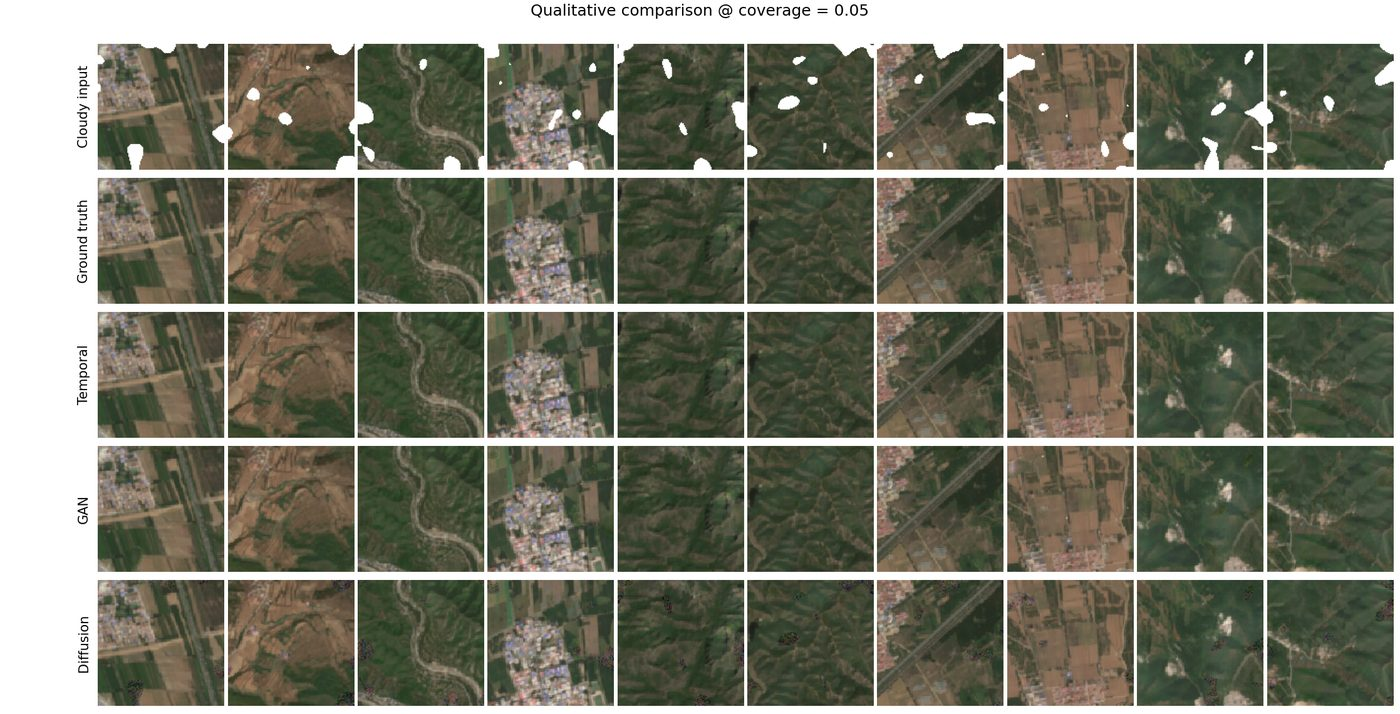 | 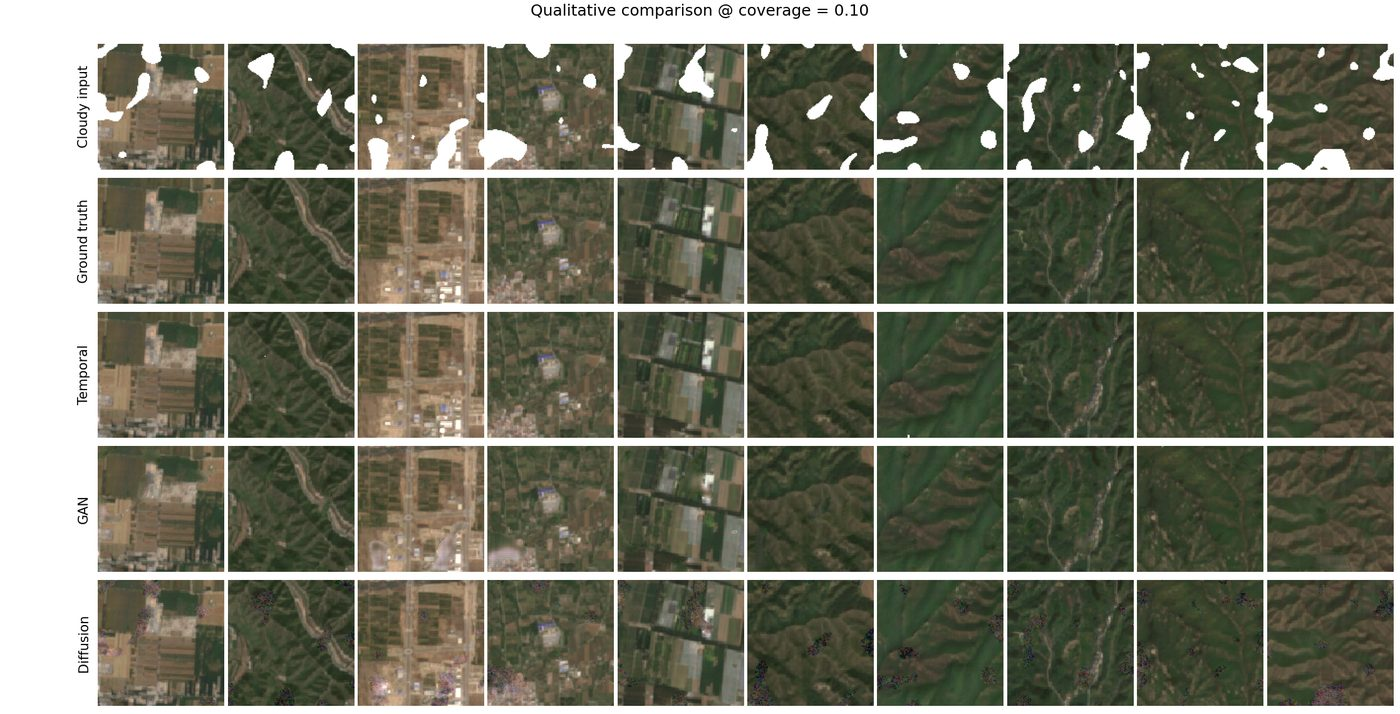 |

| cloud coverage (30%) | High cloud coverage (50%) |
| --- | --- |
| 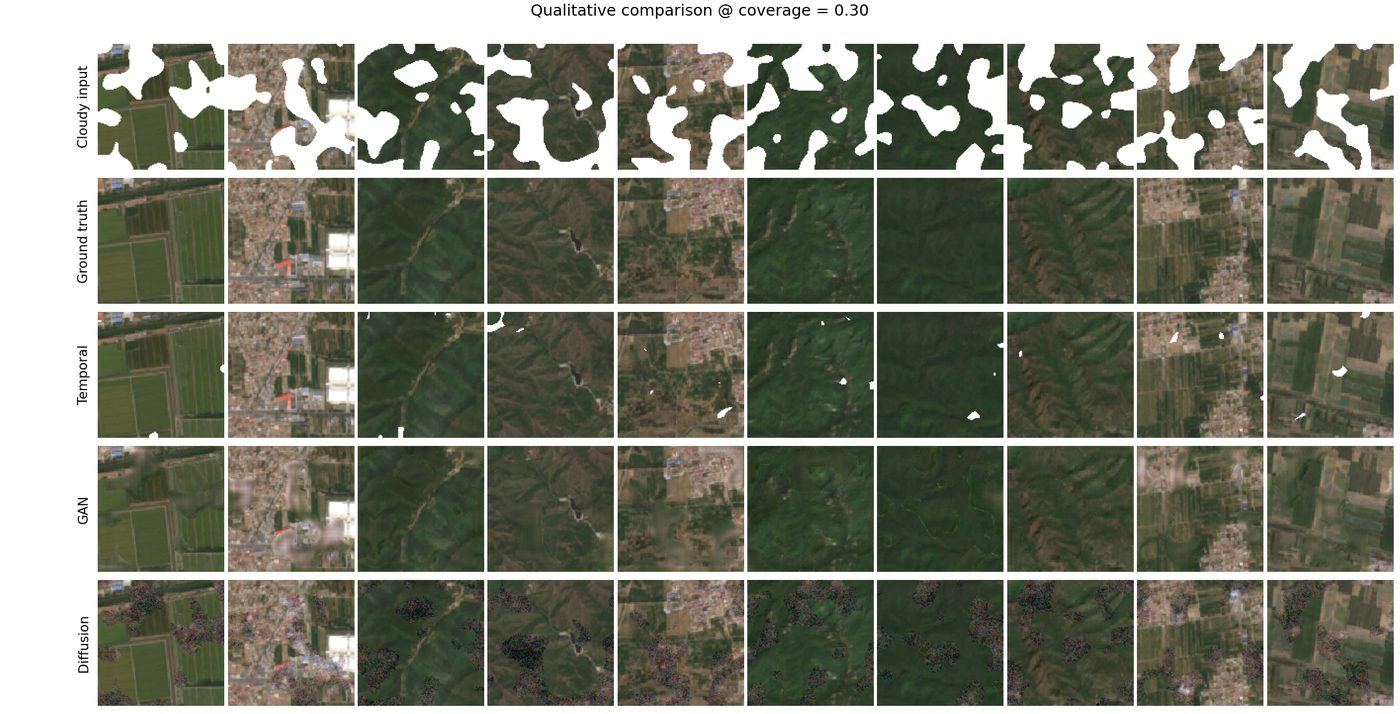 | 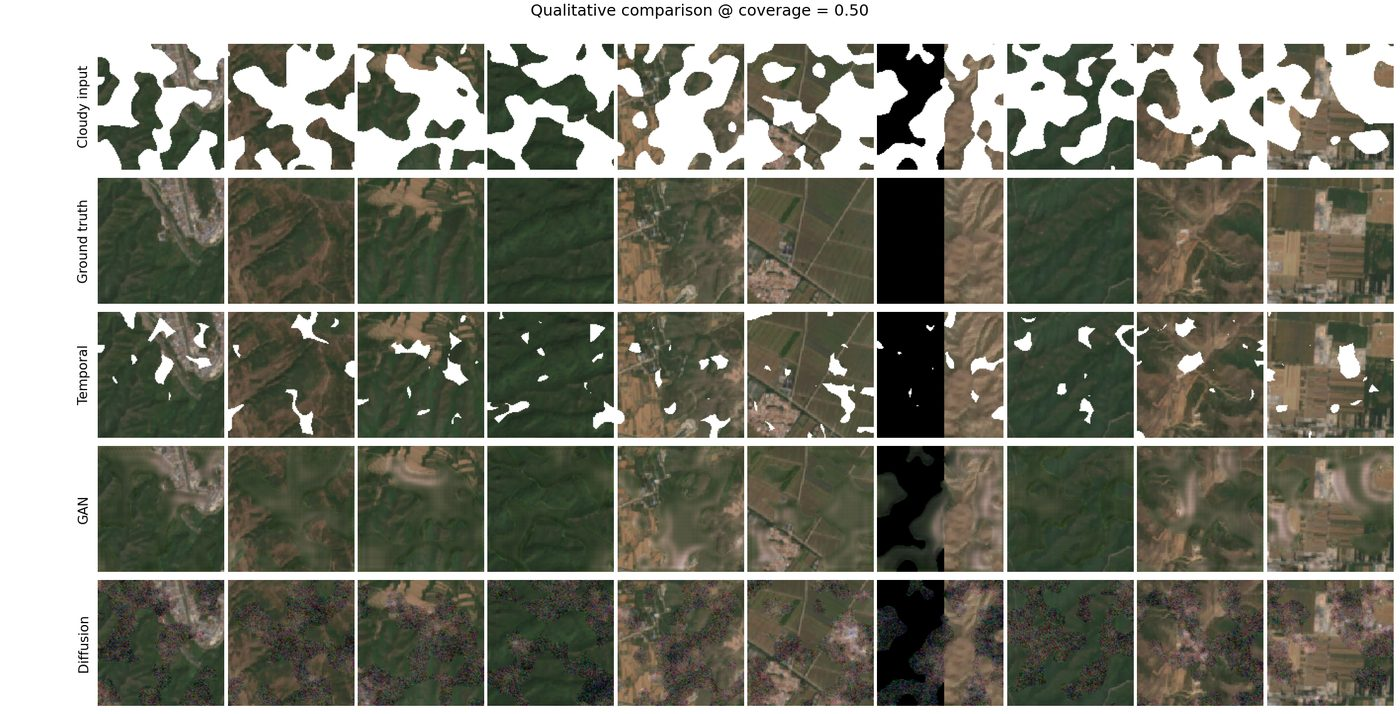 |

| cloud coverage (70%) | 
| --- |
| 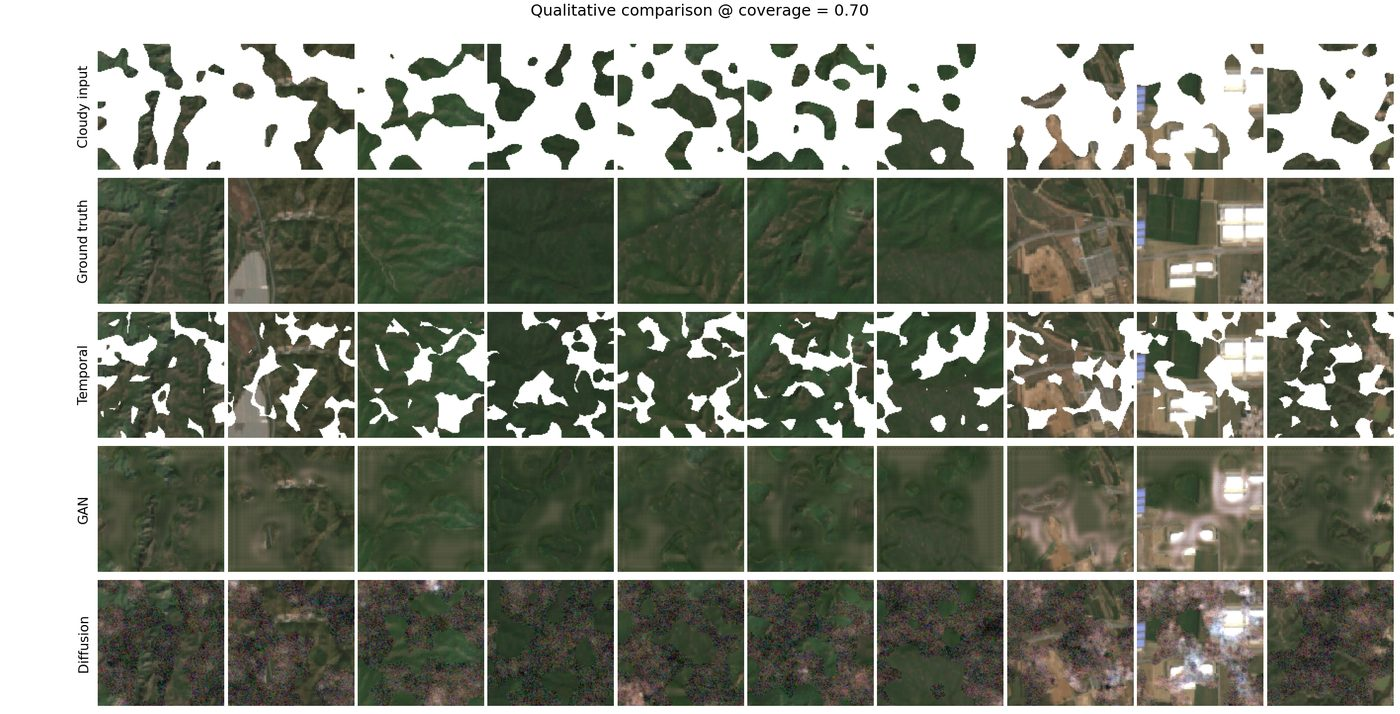 | 

*Figure 5. At 10% cloud coverage, temporal fusion is effectively perfect because at least one observation is usually clear. At 70%, the temporal method leaves large missing areas, GAN produces the most plausible reconstructions, and diffusion remains visibly noisy.*


### Failure Analysis

The failure patterns are not random; they line up closely with each method's assumptions, capacity, and training budget.

#### Failure mode 1: temporal fusion breaks when redundancy disappears
This is the clearest story in the benchmark. The temporal baseline assumes there is another clear observation to borrow from. That assumption is mostly true at 5% to 10% cloud coverage, but it fails after roughly 30% coverage, when too much information is missing from every observation.

#### Failure mode 2: hard urban and reflective patches remain difficult
At high coverage, all learned methods still struggle on white or highly reflective building areas, urban and industrial plots, and regions with drastic texture changes. The GAN performs best in these difficult patches, but some outputs are still smoother than the ground truth.

A useful way to interpret this is that the GAN is **not acting like a highly creative free-form generator** in this benchmark. Its strength is that it can learn a relatively stable supervised mapping, or hyperplane-like decision boundary, from cloudy inputs to clean targets. That makes it more reliable than diffusion in this setting.

#### Failure mode 3: diffusion is undertrained for this task setup
Diffusion underperforms here not because the idea is fundamentally wrong, but because this class of model is much more data- and compute-intensive than GAN. In this benchmark, the diffusion model likely did not receive enough data volume, enough epochs, or enough denoising iterations to show its full potential.

The presentation also points to three related weaknesses in the current setup: the backbone is still quite simple for remote-sensing textures, the optimization objective does not emphasize cloud-region recovery strongly enough, and the mask conditioning is not yet strong enough to force the model to focus on the missing areas.

#### Failure mode 4: diffusion was sensitive to implementation details
Two issues mattered a lot during debugging:
- the diffusion denoiser needed a **linear** final layer rather than the sigmoid used by the GAN generator;
- inference needed a better initialization, using the **outside-mask clean-region mean** rather than a biased cloudy-image proxy.

Those fixes were necessary to move the diffusion model from obviously broken behavior to a usable baseline. Even after those fixes, however, the current result should be read as a **limited-capacity, limited-training-budget diffusion baseline**, not as the ceiling of what diffusion could achieve with more data and longer training.


### Error Heatmaps

| coverage (5%) | coverage (10%) |
| --- | --- |
| 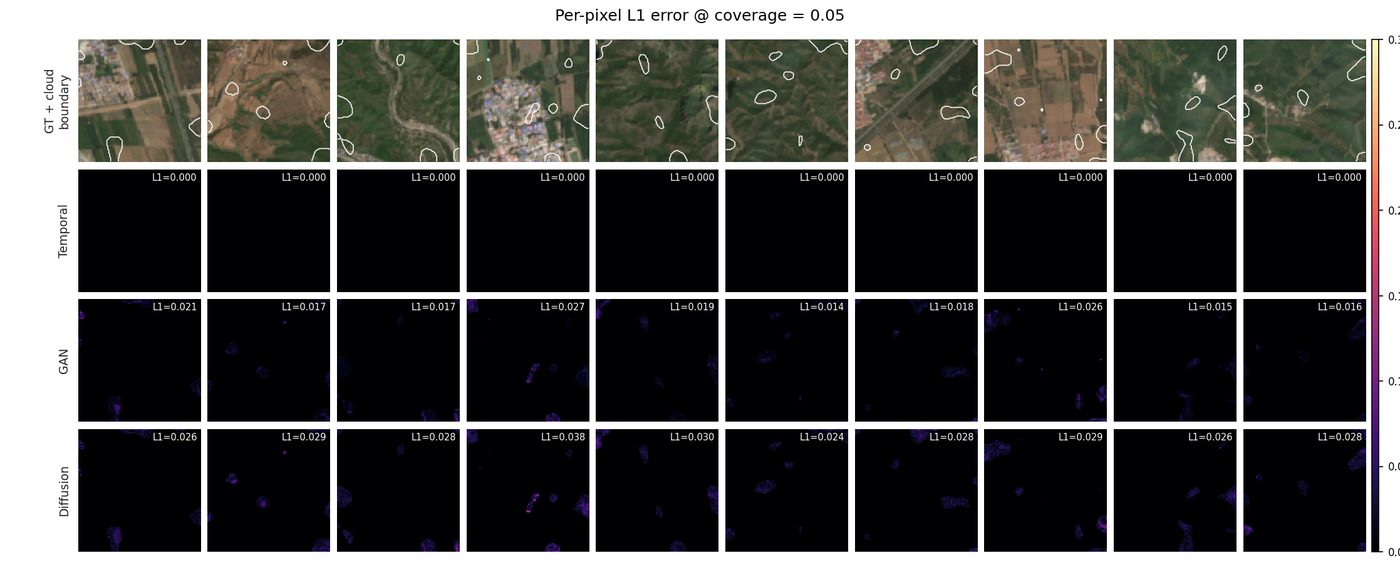 | 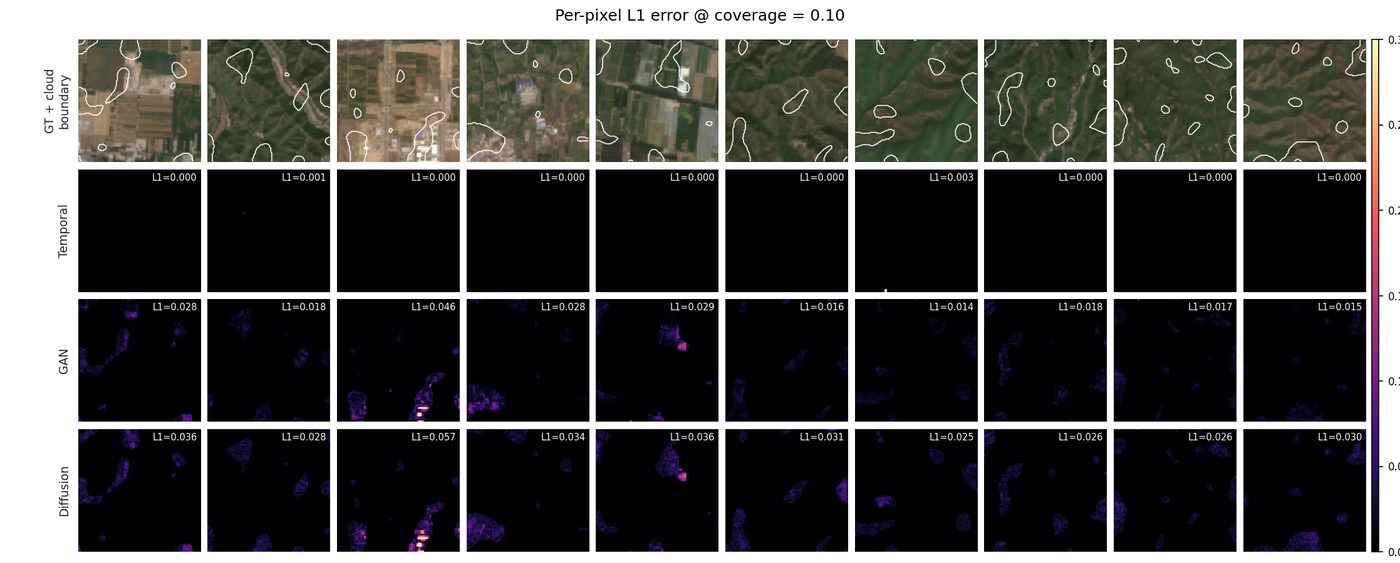 |

| coverage (30%) | coverage (50%) |
| --- | --- |
| 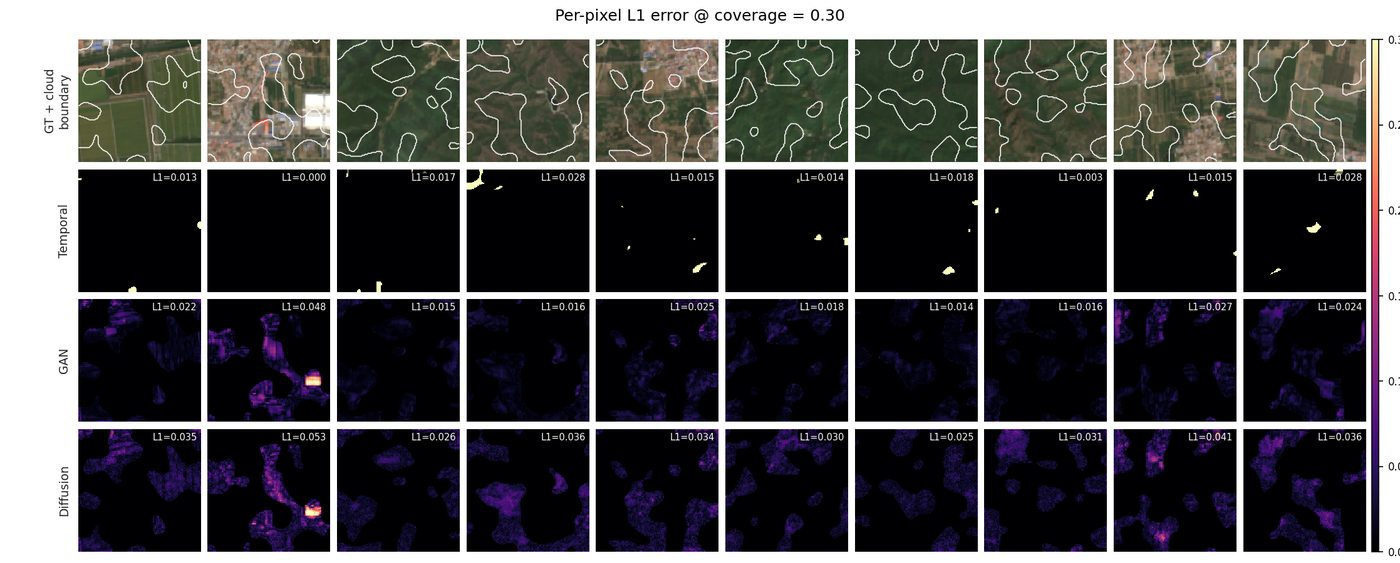 | 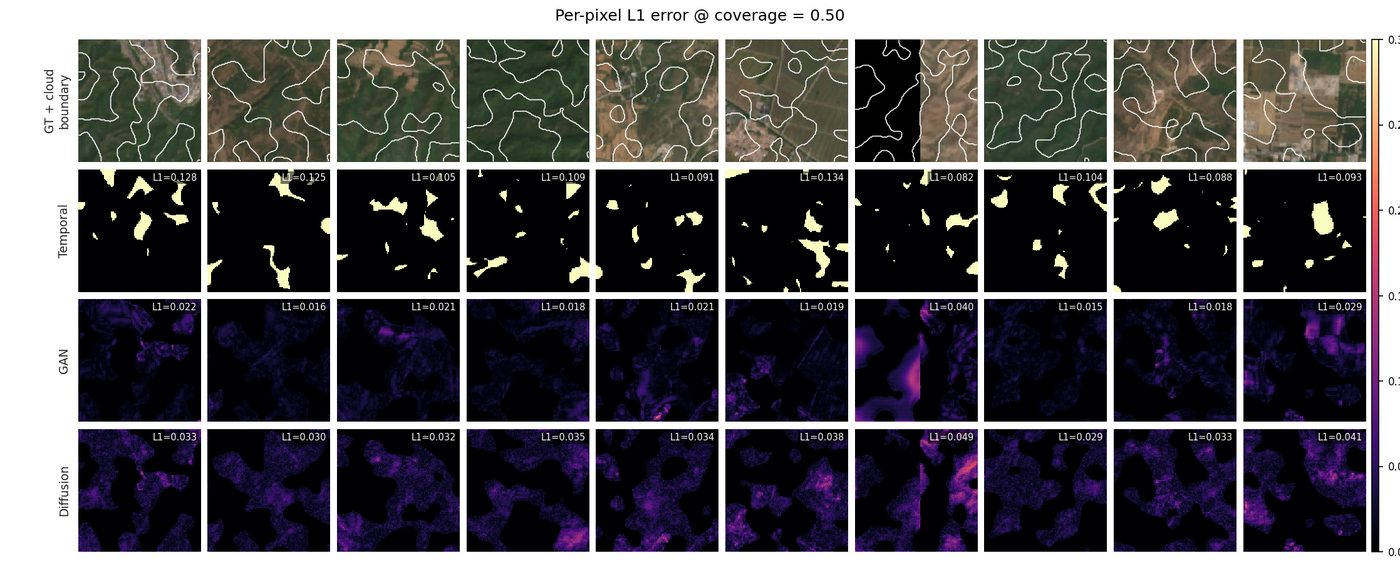 |

| coverage (70%) |
| --- | --- |
| 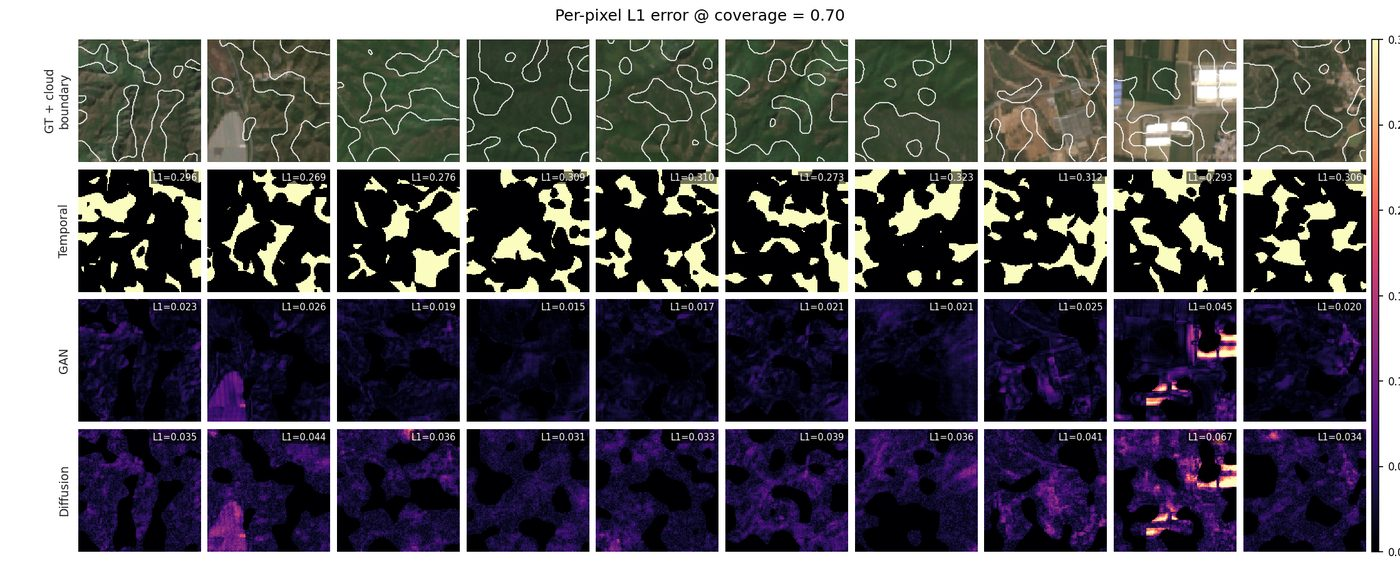 | 

*Figure 6. The error maps confirm the quantitative story: temporal error concentrates in the cloud mask and explodes at high coverage, GAN errors remain relatively small and spatially localized, and diffusion errors are broader and noisier across the reconstructed region.*


### Honest Limitations

- This is a **synthetic-cloud benchmark**, not a full real-cloud restoration study.
- The benchmark uses tiles selected in **Beijing**, while the motivating application in the presentation emphasizes **Yunnan and other cloud-prone southern regions**. That means the current study is stronger for analyzing occlusion sensitivity than for claiming direct cross-region transfer.
- The evaluation focuses on one geographic region and one seasonal window, so generalization to other cities, provinces, or climate regimes is not guaranteed.
- The diffusion model likely underestimates its own potential here because diffusion methods usually need **more training data, more compute, and more epochs** than GANs to produce strong denoising results.
- The learned models are deliberately compact because of compute constraints; a larger backbone and stronger cloud-region conditioning might improve absolute performance.
- We did not have a fully independent downstream task (for example, land-cover classification after restoration), so the current evaluation is still image-centric.


## 6. Future Work

With more time or compute, the next improvements would be:

1. **Expand the dataset, especially toward Yunnan-like or multi-region coverage**  
   The next validation step is to move beyond Beijing-only tiles and test whether the same cloud-coverage threshold still holds in cloud-prone southern regions.

2. **Train the diffusion model with more data and a much larger epoch budget**  
   The strongest diffusion-specific next step is simply to give it the scale it needs: more image tiles, more epochs, and a longer denoising training schedule. That would likely produce much better denoising behavior than what we observed here.

3. **Strengthen the diffusion objective and mask conditioning**  
   Future versions should emphasize cloud-region recovery more directly, for example through stronger mask conditioning, cloud-region-weighted losses, or an additional NDVI-consistency term.

4. **Scale the backbone for harder remote-sensing textures**  
   The current U-Net is intentionally small. More channels, deeper stages, or a more expressive denoiser should help with reflective buildings, industrial plots, and abrupt texture transitions.

5. **Keep GAN as the strong supervised benchmark while clarifying its role**  
   In this project, the GAN works well not because it is a highly creative generator, but because it learns the cloudy-to-clean mapping boundary very effectively. Future work should keep that strong baseline while testing whether larger diffusion models can eventually surpass it.

6. **Add downstream task evaluation**  
   A stronger real-world validation would measure whether restored imagery actually improves land-use interpretation, vegetation monitoring, or urban-change analysis.


## References

- Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. [https://arxiv.org/abs/1505.04597](https://arxiv.org/abs/1505.04597)
- Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). *Image-to-Image Translation with Conditional Adversarial Networks*. [https://arxiv.org/abs/1611.07004](https://arxiv.org/abs/1611.07004)
- Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. [https://arxiv.org/abs/2006.11239](https://arxiv.org/abs/2006.11239)
- Lugmayr, A., Danelljan, M., Romero, A., Yu, F., Timofte, R., & Van Gool, L. (2022). *RePaint: Inpainting using Denoising Diffusion Probabilistic Models*. [https://arxiv.org/abs/2201.09865](https://arxiv.org/abs/2201.09865)
- Google Earth Engine Data Catalog. *COPERNICUS/S2_SR_HARMONIZED*. [https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED)
- ESA. *Sentinel-2 mission overview*. [https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-2](https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-2)
